In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans


In [223]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

df = pd.read_parquet(caminho_parquet)

# Chuvas 

In [225]:
# Vou criar um DF intermediario e ir adicionando variável uma a uma. 

df_intermediario = df.copy()

In [226]:
# Chuvas 

condicoes = [
    df_intermediario['Precip'] == 0,
    (df_intermediario['Precip'] > 0) & (df_intermediario['Precip'] < 25),
    df_intermediario['Precip'] >= 25
]

valores = ['Sem chuva', 'Chuva', 'Chuva Extrema']

df_intermediario['CHUVA'] = np.select(condicoes, valores, default='Desconhecido')



In [227]:
# Verificando a quantidade de Desconhecidos. Ausente ou - 9999.0 

# Contagem absoluta
contagem_absoluta = df_intermediario['CHUVA'].value_counts()

# Contagem relativa (proporção)
contagem_relativa = df_intermediario['CHUVA'].value_counts(normalize=True)

# Exibir os resultados
print("Contagem Absoluta:")
print(contagem_absoluta)

print("\nContagem Relativa:")
print(contagem_relativa)


Contagem Absoluta:
CHUVA
Sem chuva        492347
Chuva             43505
Desconhecido      29821
Chuva Extrema       199
Name: count, dtype: int64

Contagem Relativa:
CHUVA
Sem chuva        0.870068
Chuva            0.076881
Desconhecido     0.052699
Chuva Extrema    0.000352
Name: proportion, dtype: float64


In [228]:
df_intermediario = df_intermediario[df_intermediario['CHUVA'] != 'Desconhecido']

In [229]:
df_intermediario = df_intermediario.drop(columns=['Precip'])
df_intermediario = df_intermediario.drop(columns=['Dt_Hr'])
df_intermediario = df_intermediario.drop(columns=['timestamp'])
df_intermediario = df_intermediario.drop(columns=['Lat'])
df_intermediario = df_intermediario.drop(columns=['Long'])
df_intermediario = df_intermediario.drop(columns=['Alt'])

# Não quero explicar a variavel com a variavel 
df_intermediario = df_intermediario.drop(columns=['PRECIPITAÇÃO TOTAL primeira hora anterior'])
df_intermediario = df_intermediario.drop(columns=['PRECIPITAÇÃO TOTAL segunda hora anterior'])
df_intermediario = df_intermediario.drop(columns=['PRECIPITAÇÃO TOTAL terceira hora anterior'])




In [230]:
df_intermediario.columns

Index(['Pres_Atm', 'Pres_Atm_max', 'Pres_Atm_min', 'Rad', 'Temp_Amb',
       'Pto_Orv', 'Temp_Amb_max', 'Temp_Amb_min', 'Pto_Orv_max', 'Pto_Orv_min',
       'Umidade_max', 'Umidade_min', 'Umidade', 'Vento_dir', 'Vento_raj',
       'Vento_vel', 'ESTACAO', 'estacao_do_ano', 'hora', 'turno',
       'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
       'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
       'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
       'VARIACAO QUARTA HORA ANTERIOR PRESSAO',
       'VARIACAO QUINTA HORA ANTERIOR PRESSAO',
       'VARIACAO SEXTA HORA ANTERIOR PRESSAO',
       'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO',
       'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO',
       'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO',
       'VARIACAO PRIMEIRA HORA ANTERIOR UMIDA

In [231]:
df_intermediario.head()

,Pres_Atm,Pres_Atm_max,Pres_Atm_min,Rad,Temp_Amb,Pto_Orv,Temp_Amb_max,Temp_Amb_min,Pto_Orv_max,Pto_Orv_min,...,DIRECAO DO VENTO PRIMEIRA HORA ANTERIOR,DIRECAO DO VENTO SEGUNDA HORA ANTERIOR,DIRECAO DO VENTO TERCEIRA HORA ANTERIOR,DIRECAO DO VENTO QUARTA HORA ANTERIOR,DIRECAO DO VENTO QUINTA HORA ANTERIOR,DIRECAO DO VENTO SEXTA HORA ANTERIOR,VELOCIDADE DO VENTO PRIMEIRA HORA ANTERIOR,VELOCIDADE DO VENTO SEGUNDA HORA ANTERIOR,VELOCIDADE DO VENTO TERCEIRA HORA ANTERIOR,CHUVA
18,1010.0,1010.1,1010.0,100.8,23.5,21.1,23.8,23.5,21.2,21.1,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Sem chuva
19,1010.4,1010.4,1010.3,35.6,23.2,21.0,23.3,23.2,21.1,20.7,...,224.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,4.6,-9999.0,-9999.0,Sem chuva
35,1013.2,1013.2,1013.1,91.2,23.6,19.3,23.6,23.1,19.3,18.2,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,Sem chuva
36,1013.5,1013.5,1013.2,141.0,23.9,20.6,23.9,23.6,20.6,19.4,...,37.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,0.4,-9999.0,-9999.0,Sem chuva
37,1013.8,1013.9,1013.8,428.8,25.0,19.3,25.0,24.3,19.5,19.0,...,104.0,37.0,-9999.0,-9999.0,-9999.0,-9999.0,0.9,0.4,-9999.0,Sem chuva


# Pressão - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO - Kmeans

In [233]:
df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO']].isnull().sum()


VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO    394
dtype: int64

In [234]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'])


In [235]:
#'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
#'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
#'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'

# ----------------------------------------------------------------------------------------------------

# Definir a variável para aplicar o K-Means
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO']]

# Definir o número de clusters.
# Vou usar 2 para baixo, medio e alto. 
n_clusters = 3  

# Aplicar o K-Means
kmeans = KMeans(n_clusters = n_clusters, random_state= 10)
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters
centroids = kmeans.cluster_centers_
print("Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO': ", centroids)

# Atribuir rótulos aos clusters de temperatura com base nos centróides
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'] = df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'].map({
    0: 'Medio',      # Cluster com centróide 0.52336831
    1: 'baixo',     # Cluster com 0.22598886
    2: 'Alto' ,     # Cluster com centróide 0.94487105
})

# ----------------------------------------------------------------------------------------------------

# Centroide, o cluster vai pertencer a menor distancia do centroid. 

Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO':  [[0.52336831]
 [0.22598886]
 [0.99910914]]


In [236]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'].value_counts()


VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
Medio    251503
baixo    200078
Alto      84076
Name: count, dtype: int64

In [237]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'].describe()

count    535657.000000
mean          0.486963
std           0.298690
min           0.000000
25%           0.300000
50%           0.400000
75%           0.600000
max          11.900000
Name: VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO, dtype: float64

In [238]:
percentis = np.arange(90, 101, 1)

valores_percentis = np.percentile(df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'], percentis) 
valores_percentis

df_percentis = pd.DataFrame({'Percentis da VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO': percentis, 'Valor': valores_percentis})
# pd.set_option('display.max_rows', None)

print(df_percentis)

    Percentis da VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO  Valor
0                                                  90       0.9
1                                                  91       0.9
2                                                  92       0.9
3                                                  93       0.9
4                                                  94       1.0
5                                                  95       1.0
6                                                  96       1.1
7                                                  97       1.1
8                                                  98       1.2
9                                                  99       1.4
10                                                100      11.9


In [239]:
df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS', 'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS']].head()

,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS,VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
18,0.1,1,baixo
19,0.1,1,baixo
35,0.1,1,baixo
36,0.3,1,baixo
37,0.1,1,baixo


In [240]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'].value_counts()


VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
Medio    251503
baixo    200078
Alto      84076
Name: count, dtype: int64

In [241]:
#from sklearn.metrics import silhouette_score

#X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO']]
#labels = df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS']

#sil_score = silhouette_score(X, labels)
#print(f"Coeficiente de Silhueta: {sil_score:.3f}")

# Pressão - VARIACAO SEGUNDA HORA ANTERIOR PRESSAO - Kmeans

In [243]:
df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO']].isnull().sum()

# 319 dados faltantes, vão ser removidos. 

VARIACAO SEGUNDA HORA ANTERIOR PRESSAO    319
dtype: int64

In [244]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO'])



In [245]:
X = df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO']]

n_clusters = 3  

# Aplicar o K-Means
kmeans = KMeans(n_clusters = n_clusters, random_state= 10)

df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters 
centroids = kmeans.cluster_centers_

print("Centróides de 'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO': ", centroids)

# Atribuir rótulos aos clusters de temperatura com base nos centróides
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'] = df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS'].map({
    0: 'baixo',      # Cluster com centróide 0.52336831
    1: 'medio',     # Cluster com 0.22598886
    2: 'alto'      # Cluster com centróide 0.94487105
})

# ----------------------------------------------------------------------------------------------------

# Centroide, o cluster vai pertencer a menor distancia do centroid. 

Centróides de 'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO':  [[0.27556618]
 [0.61576755]
 [1.10722987]]


In [246]:
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO'].describe()

count    535338.000000
mean          0.485847
std           0.299290
min           0.000000
25%           0.300000
50%           0.400000
75%           0.600000
max          11.900000
Name: VARIACAO SEGUNDA HORA ANTERIOR PRESSAO, dtype: float64

In [247]:
percentis = np.arange(90, 101, 1)

valores_percentis = np.percentile(df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO'], percentis) 
valores_percentis

df_percentis = pd.DataFrame({'Percentis da VARIACAO SEGUNDA HORA ANTERIOR PRESSAO': percentis, 'Valor': valores_percentis})
# pd.set_option('display.max_rows', None)

print(df_percentis)


    Percentis da VARIACAO SEGUNDA HORA ANTERIOR PRESSAO  Valor
0                                                  90      0.9
1                                                  91      0.9
2                                                  92      0.9
3                                                  93      0.9
4                                                  94      1.0
5                                                  95      1.0
6                                                  96      1.1
7                                                  97      1.1
8                                                  98      1.2
9                                                  99      1.4
10                                                100     11.9


In [248]:
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'].value_counts()


VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
baixo    282948
medio    198046
alto      54344
Name: count, dtype: int64

In [249]:
#import time
#from sklearn.metrics import silhouette_score

# Iniciar o temporizador
#start_time = time.time()

# Calcular o coeficiente de silhueta
#X = df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO']]
#labels = df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS']

#sil_score = silhouette_score(X, labels)

# Tempo total decorrido
#elapsed_time = time.time() - start_time

#print(f"Coeficiente de Silhueta: {sil_score:.3f}")
#print(f"Tempo de execução: {elapsed_time:.4f} segundos")


# Pressão - VARIACAO TERCEIRA HORA ANTERIOR PRESSAO - Kmeans

In [251]:
df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']].isnull().sum()


VARIACAO TERCEIRA HORA ANTERIOR PRESSAO    309
dtype: int64

In [252]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'])


In [253]:
X = df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']]

n_clusters = 3  

# Aplicar o K-Means
kmeans = KMeans(n_clusters = n_clusters, random_state= 10)

df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters 
centroids = kmeans.cluster_centers_

print("Centróides de 'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO': ", centroids)

# Atribuir rótulos aos clusters de temperatura com base nos centróides
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'] = df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'].map({
    0: 'medio',      # Cluster com centróide 0.52336831
    1: 'baixo',     # Cluster com 0.22598886
    2: 'alto'      # Cluster com centróide 0.94487105
})


Centróides de 'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO':  [[0.7478232 ]
 [0.31972785]
 [1.47147111]]


In [254]:
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'].value_counts()


VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
baixo    352826
medio    167425
alto      14778
Name: count, dtype: int64

In [255]:
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'].describe()

count    535029.000000
mean          0.485503
std           0.299352
min           0.000000
25%           0.300000
50%           0.400000
75%           0.600000
max          11.900000
Name: VARIACAO TERCEIRA HORA ANTERIOR PRESSAO, dtype: float64

In [256]:
percentis = np.arange(90, 101, 1)

valores_percentis = np.percentile(df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'], percentis) 
valores_percentis

df_percentis = pd.DataFrame({'Percentis da VARIACAO TERCEIRA HORA ANTERIOR PRESSAO': percentis, 'Valor': valores_percentis})
# pd.set_option('display.max_rows', None)

print(df_percentis)


    Percentis da VARIACAO TERCEIRA HORA ANTERIOR PRESSAO  Valor
0                                                  90       0.9
1                                                  91       0.9
2                                                  92       0.9
3                                                  93       0.9
4                                                  94       1.0
5                                                  95       1.0
6                                                  96       1.1
7                                                  97       1.1
8                                                  98       1.2
9                                                  99       1.4
10                                                100      11.9


In [257]:
#import time
#from sklearn.metrics import silhouette_score

# Iniciar o temporizador
#start_time = time.time()
 
# Calcular o coeficiente de silhueta
#X = df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']]
#labels = df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS']

#sil_score = silhouette_score(X, labels)

# Tempo total decorrido
#elapsed_time = time.time() - start_time

#print(f"Coeficiente de Silhueta: {sil_score:.3f}")
#print(f"Tempo de execução: {elapsed_time:.4f} segundos")

# Salvando Arquivo Intermediario 

In [259]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"
df_intermediario.to_parquet(caminho_parquet, index=False)

In [260]:
# df_intermediario.columns

# TEMPERATURA - VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE - Kmeans

In [262]:
#'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
#'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
#'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',

In [263]:
df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE']].isnull().sum()

VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE    135
dtype: int64

In [264]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'])


In [267]:
# Remover as linhas onde a coluna tem valores maiores que 50, só tenho 1 caso, no caso é devido a dados faltantes.  
df_intermediario = df_intermediario[df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE'] <= 50]


# A menor temperatura já registrada no RJ foi de  8,3ºC , temos temperaturas abaixo nos nossos dados, até negativas, serão removidas. 

df_intermediario = df_intermediario[df_intermediario['Temp_Amb_min'] >= 8]


In [325]:
df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE']].describe()

,VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE
count,534029.000000
mean,1.139294
std,0.973188
min,0.000000
25%,0.500000
50%,0.900000
75%,1.500000
max,18.200000


In [329]:
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE']]

n_clusters = 3  

# Aplicar o K-Means
kmeans = KMeans(n_clusters = n_clusters, random_state= 10)

df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters 
centroids = kmeans.cluster_centers_

print("Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE': ", centroids)


Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE':  [[1.78414857]
 [0.58340383]
 [4.23685942]]


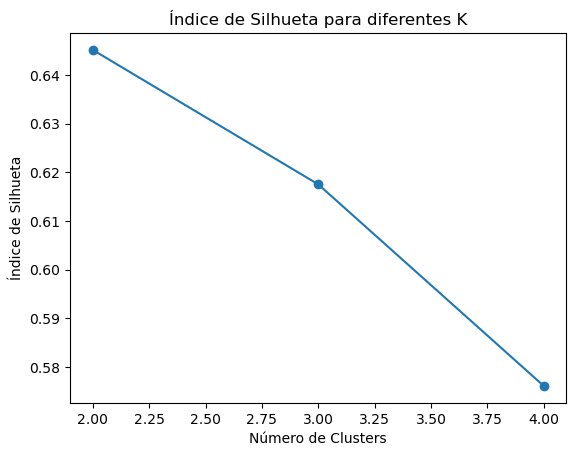

In [331]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 5)  # Testar de 2 a 5 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)'

# Plotando o gráfico do índice de silhueta
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Índice de Silhueta')
plt.title('Índice de Silhueta para diferentes K')
plt.show()


In [333]:
df.columns

Index(['Dt_Hr', 'timestamp', 'Lat', 'Long', 'Alt', 'Precip', 'Pres_Atm',
       'Pres_Atm_max', 'Pres_Atm_min', 'Rad', 'Temp_Amb', 'Pto_Orv',
       'Temp_Amb_max', 'Temp_Amb_min', 'Pto_Orv_max', 'Pto_Orv_min',
       'Umidade_max', 'Umidade_min', 'Umidade', 'Vento_dir', 'Vento_raj',
       'Vento_vel', 'ESTACAO', 'estacao_do_ano', 'hora', 'turno',
       'PRECIPITAÇÃO TOTAL primeira hora anterior',
       'PRECIPITAÇÃO TOTAL segunda hora anterior',
       'PRECIPITAÇÃO TOTAL terceira hora anterior',
       'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
       'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
       'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
       'VARIACAO QUARTA HORA ANTERIOR PRESSAO',
       'VARIACAO QUINTA HORA ANTERIOR PRESSAO',
       'VARIACAO SEXTA HORA ANTERIOR PRESSAO',
       'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIAC